# Notebook 6: Linearized RBC Model

In [1]:
using NBInclude  #to load other notebooks
using StatsBase
using Plots;

In [2]:
@nbinclude("gensys.ipynb"); #loads gensys

In [3]:
# Structural parameters
β=.99   #time discount factor
γ=1.    #EIS inverse
ψ=1.    #Frisch inverse
δ=.025  #capital depreciation
α=1/3   #capital share
ρ=.9    #persistence of tfp shocks
σ=.8;   #100SD of tfp shocks

In [4]:
# Non-stochastic steady-state
K_Y=(β*α)/(1-β*(1-δ)) 
I_Y=δ*(K_Y) 
C_Y=1-I_Y;

Specify the matrices for the system:
\begin{equation}\label{sims}
   	\Gamma_0 x_{t} =  \Gamma_1 x_{t-1} + C + \Psi \varepsilon_t + \Pi \eta_t
\end{equation}
with
\begin{equation}
   		x_t = [ c_t, i_t, k_t, y_t, l_t, w_t, r_t, a_t, c_{t+1}, r_{t+1}]'.
\end{equation}

In [5]:
# Initialization 
nx=10     #number of variables
ns=1      #number of shocks
ne=2      #number of expectational errors
G0=zeros(nx,nx)
G1=zeros(nx,nx)
C=zeros(nx,1)
Psi=zeros(nx,ns)
Pi=zeros(nx,ne);

In [6]:
# Assign indexes
c,i,k,y,l,w,r,a,Ec,Er=1:nx
as=1
cx,rx=1:ne;

In [7]:
# Fill out the matrices with the equilibrium conditions
# 1) Euler equation
G0[1,c]=1
G0[1,Ec]=-1
G0[1,Er]=(1-β*(1-δ))/γ
# 2) Labor supply
G0[2,c]=γ
G0[2,l]=ψ
G0[2,w]=-1
# 3) Capital renting
G0[3,a]=1
G0[3,l]=(1-α)
G0[3,r]=-1
G1[3,k]=(1-α)
# 4) Labor demand
G0[4,a]=1
G0[4,l]=-α
G0[4,w]=-1
G1[4,k]=-α
# 5) Production function
G0[5,a]=1
G0[5,l]=1-α
G0[5,y]=-1
G1[5,k]=-α
# 6) Market clearing
G0[6,y]=1
G0[6,c]=-C_Y
G0[6,i]=-I_Y
# 7) Capital accumulation
G0[7,k]=1
G0[7,i]=-δ
G1[7,k]=(1-δ)
# 8) TFP
G0[8,a]=1
G1[8,a]=ρ
Psi[8,as]=1
# 9) Expected consumption
G0[9,c]=1
G1[9,Ec]=1
Pi[9,cx]=1
# 10) Expected rental rate
G0[10,r]=1
G1[10,Er]=1
Pi[10,rx]=1;

In [8]:
# Solve the system with gensys
G,_,impact,eu=gensys(G0,G1,C,Psi,Pi)
if sum(eu)<2
    println("Equilibrium is not saddle-path stable")
end

2-element Vector{Int64}:
 1
 1

In [11]:
# Find the state variables
states_idx=unique([idx[2] for idx in findall(abs.(G) .>= 1e-6)])
vars=[:c,:i,:k,:y,:l,:w,:r,:a,:Ec,:Er]
states= vars[states_idx] 
println("State variables are $states")
# Linear policy functions 
G[c,states_idx]
G[k,states_idx];

State variables are [:k, :a]


2-element Vector{Float64}:
 0.5565381732033411
 0.25155757528041184

In [12]:
#Compute the impulse response functions
SDX = diagm([σ])
T=41
IR = zeros(nx,ns,T)
for ii in 1:ns
    e = zeros(ns);e[ii] = 1.
    for t=1:T
        if t == 1
            IR[:,ii, t]=impact*(SDX*e)
        else
            IR[:,ii, t]=G*IR[:,ii, t-1]
        end
    end
end
IR[abs.(IR).< 10^-6].= 0;

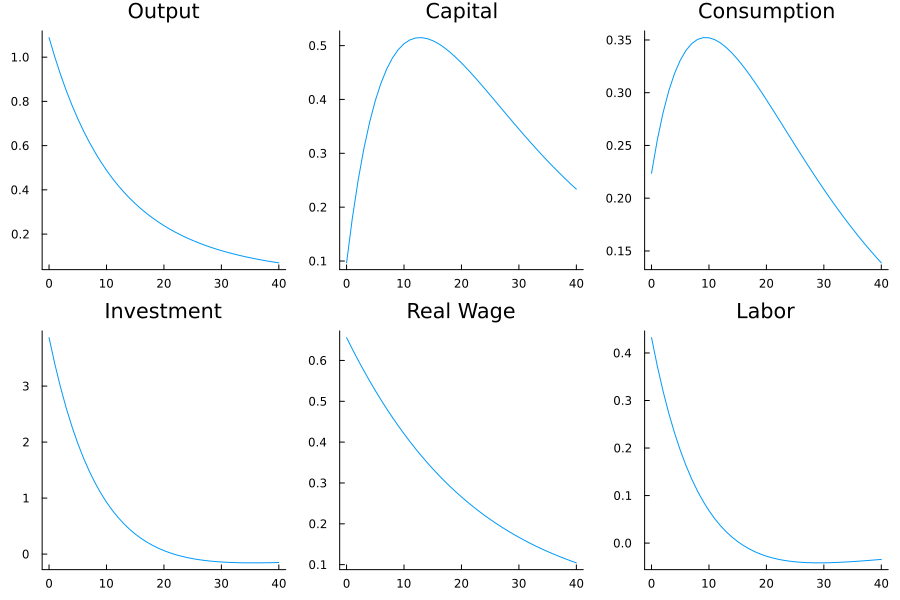

In [13]:
# Impulse Responses to a TFP shock
p_y=plot(0:(T-1),IR[y,1,:],grid=false,label=false,framestle=:box,title="Output") #xlims=(0,T-1),xticks=0:4:(T-1))
p_k=plot(0:(T-1),IR[k,1,:],grid=false,label=false,framestle=:box,title="Capital")
p_c=plot(0:(T-1),IR[c,1,:],grid=false,label=false,framestle=:box,title="Consumption")
p_i=plot(0:(T-1),IR[i,1,:],grid=false,label=false,framestle=:box,title="Investment")
p_w=plot(0:(T-1),IR[w,1,:],grid=false,label=false,framestle=:box,title="Real Wage")
p_l=plot(0:(T-1),IR[l,1,:],grid=false,label=false,framestle=:box,title="Labor")
#p_r=plot(0:(T-1),IR[r,1,:],grid=false,label=false,framestle=:box,title="Real Rate")
# Create a tiny empty plot with just vertical annotation
#p_label = plot([NaN], [NaN], framestyle = :none,grid = false,xlims = (0,1), ylims = (0,1),ticks = false,label=false)
#annotate!(p_label, 0.5, 0.5, text("Response to Technology", 12, rotation=90))
#plot(p_label,p_y, p_k, p_c,p_label,p_i, p_w, p_r,layout = (2, 4),size = (900, 600))
plot(p_y, p_k, p_c,p_i, p_w, p_l,layout = (2, 3),size = (900, 600))
#plot_title=("Impulse Responses to a TFP shock"))
#p_r=plot(0:(T-1),IR[r,1,:],grid=false,label=false,framestle=:box,title="Real Rate")

In [15]:
# Simulate the economy
burn=200
T=200 # set to 10000 for a long sample
ε=(randn(burn+T)*σ)[:,:]  #random draws of tfp shocks
Xsim=zeros(nx,burn+T)
for t = 1:(burn+T)
    if t == 1
        Xsim[:,t]=impact*ε[t,:] 
    else
        Xsim[:,t]=G*Xsim[:,t-1]+impact*ε[t,:] 
    end
end;
vObs=[:c,:i,:y,:l,:w]
Obs=[Xsim[c,:] Xsim[i,:] Xsim[y,:] Xsim[l,:] Xsim[w,:]]'
Obs=Obs[:,burn+1:end]
nObs=size(Obs)[1];

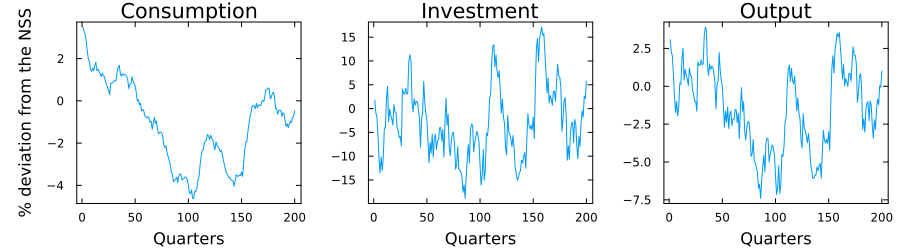

In [16]:
# Simulated Time Series
p_c=plot(Obs[1,:],label="",grid=false,title="Consumption",framestyle=:box,xlabel="Quarters",ylabel="% deviation from the NSS",left_margin=8Plots.mm)
p_i=plot(Obs[2,:],label="",grid=false,title="Investment",framestyle=:box,xlabel="Quarters",left_margin=3Plots.mm)
p_y=plot(Obs[3,:],label="",grid=false,title="Output",framestyle=:box,xlabel="Quarters",left_margin=3Plots.mm)
plot(p_c, p_i,p_y,layout=(1,3),size = (900, 250), bottom_margin=5Plots.mm)
#plot_title=("Simulated Time Series")

In [17]:
sdy=std(Obs[3,:])
sdMat=[ std(Obs[i,:])/sdy for i in 1:nObs] 
[vObs sdMat]

5×2 Matrix{Any}:
 :c  0.716509
 :i  2.79779
 :y  1.0
 :l  0.311893
 :w  0.812044

In [18]:
#correlation matrices
case=[0 1 2 3 4]
ncase=size(case,2)
corMat=zeros(nObs,nObs,ncase)
for k in 1:ncase 
    for i in 1:nObs
        for j in 1:nObs
            corMat[i,j,k] = cor(Obs[i,1+case[k]:end],Obs[j,1:end-case[k]])
        end
    end 
end
corMat_y=[[:var :0 :1 :2 :3 :4]
           vObs corMat[:,3,:]]

6×6 Matrix{Any}:
 :var  0         1         2         3         4
 :c    0.784551  0.803544  0.818266  0.827687  0.8312
 :i    0.86013   0.730535  0.624357  0.526506  0.43814
 :y    1.0       0.92436   0.859696  0.796726  0.735189
 :l    0.701942  0.561157  0.447244  0.343645  0.251596
 :w    0.961856  0.924713  0.891738  0.857018  0.819663